In [1]:
!pip install google-play-scraper transformers torch pandas matplotlib seaborn -q
print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


In [2]:
from google_play_scraper import reviews, Sort
import csv

APP_ID = 'com.telkom.tracencare'
APP_URL = f'https://play.google.com/store/apps/details?id={APP_ID}'
print(f'🔗 URL: {APP_URL}')

result, _ = reviews(
    APP_ID,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'
with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:
        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f'✅ Berhasil menyimpan {len(result)} ulasan ke {filename}')

🔗 URL: https://play.google.com/store/apps/details?id=com.telkom.tracencare
✅ Berhasil menyimpan 1000 ulasan ke ulasan_google_play.csv


In [3]:
import pandas as pd

df = pd.read_csv('ulasan_google_play.csv')
df['content'] = df['content'].fillna('').astype(str)
df['at'] = pd.to_datetime(df['at'])
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f'📊 Total ulasan : {len(df)}')
print(f'📅 Rentang data : {df["at"].min().date()} s/d {df["at"].max().date()}')
df.head()

📊 Total ulasan : 1000
📅 Rentang data : 2025-11-20 s/d 2026-05-03


,userName,score,at,content
0,Gus Mal,5,2026-05-03 12:16:38,bagus
1,Riyu Aditya Lintang Pratama,1,2026-05-03 11:52:42,gak bisa login padahal pin dan nomer telpon su...
2,Sulastri Era,5,2026-05-03 07:07:58,pelayanan prima
3,Arista_88,1,2026-05-02 11:38:51,tolong di perbaiki aplikasinya. karena susah m...
4,Andre Nakiatu,1,2026-05-02 11:36:28,aplikasi cacat udah diganti pin masih aja tete...


In [4]:
from transformers import pipeline

MODEL_NAME = 'w11wo/indonesian-roberta-base-sentiment-classifier'
print(f'⏳ Memuat model RoBERTa... (tunggu 2-3 menit pertama kali)')

sentiment_pipeline = pipeline(
    task='text-classification',
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512
)

print('✅ Model berhasil dimuat!')
test = sentiment_pipeline('Aplikasi ini sangat membantu!')
print(f'🧪 Tes: {test}')

⏳ Memuat model RoBERTa... (tunggu 2-3 menit pertama kali)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Model berhasil dimuat!
🧪 Tes: [{'label': 'positive', 'score': 0.9935092329978943}]


In [5]:
from tqdm.notebook import tqdm

texts = df['content'].tolist()
print(f'🔍 Menganalisis {len(texts)} ulasan...')

hasil_sentimen = []
BATCH_SIZE = 16

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    results = sentiment_pipeline(batch)
    hasil_sentimen.extend(results)

df['sentimen']   = [r['label'] for r in hasil_sentimen]
df['confidence'] = [round(r['score'], 4) for r in hasil_sentimen]

label_map = {
    'positive': 'Positif',
    'negative': 'Negatif',
    'neutral' : 'Netral',
}
df['sentimen_id'] = df['sentimen'].map(label_map).fillna(df['sentimen'])

print('✅ Selesai!')
df[['userName','score','sentimen_id','confidence','content']].head(10)

🔍 Menganalisis 1000 ulasan...


  0%|          | 0/63 [00:00<?, ?it/s]

✅ Selesai!


,userName,score,sentimen_id,confidence,content
0,Gus Mal,5,Positif,0.7057,bagus
1,Riyu Aditya Lintang Pratama,1,Negatif,0.9029,gak bisa login padahal pin dan nomer telpon su...
2,Sulastri Era,5,Netral,0.5424,pelayanan prima
3,Arista_88,1,Negatif,0.9715,tolong di perbaiki aplikasinya. karena susah m...
4,Andre Nakiatu,1,Negatif,0.9922,aplikasi cacat udah diganti pin masih aja tete...
5,trisakti lorina,2,Negatif,0.9905,kenapa gak bisa diakses si udah download dftar...
6,khaidir sulaiman,5,Positif,0.7057,bagus
7,Ela Sukarya,5,Positif,0.5453,Alhamdulillah bisa mengetahui gula darah dan t...
8,Nandar Yanuar,5,Positif,0.9744,Sangat membantu
9,Royo Prasilo,5,Positif,0.9559,"Informatif, Baik & bagus."


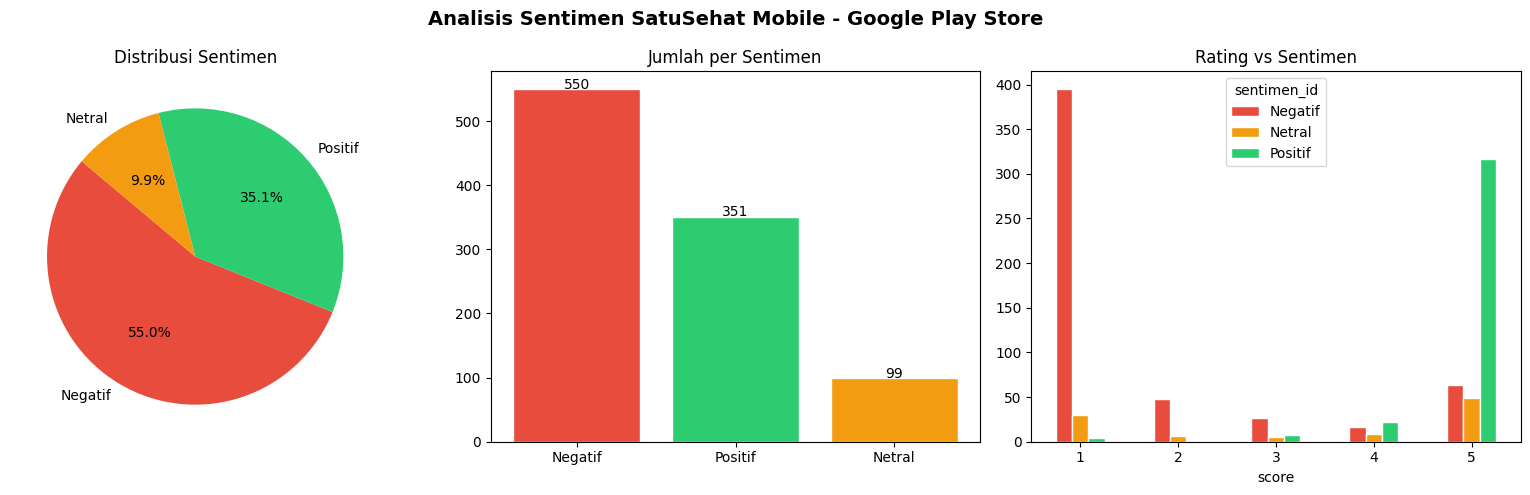

✅ Grafik disimpan!


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analisis Sentimen SatuSehat Mobile - Google Play Store', fontsize=14, fontweight='bold')

COLORS = {'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
counts = df['sentimen_id'].value_counts()
colors_list = [COLORS.get(l, '#999') for l in counts.index]

axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_list, startangle=140)
axes[0].set_title('Distribusi Sentimen')

bars = axes[1].bar(counts.index, counts.values, color=colors_list, edgecolor='white')
axes[1].set_title('Jumlah per Sentimen')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(val), ha='center')

sentiment_rating = df.groupby(['score','sentimen_id']).size().unstack(fill_value=0)
sentiment_rating.plot(kind='bar', ax=axes[2],
                      color=[COLORS.get(c,'#999') for c in sentiment_rating.columns],
                      edgecolor='white')
axes[2].set_title('Rating vs Sentimen')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('hasil_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')

In [7]:
output_file = 'hasil_analisis_sentimen.csv'
df[['userName','score','at','content','sentimen_id','confidence']].to_csv(
    output_file, index=False, encoding='utf-8'
)

print(f'✅ Tersimpan: {output_file}')
print(f'\n📊 RINGKASAN HASIL')
print(f'{"="*35}')
print(f'App     : SatuSehat Mobile')
print(f'App ID  : {APP_ID}')
print(f'URL     : {APP_URL}')
print(f'Total   : {len(df)} ulasan')
print(f'Model   : RoBERTa Indonesia')
print()
for label, count in df['sentimen_id'].value_counts().items():
    pct = count/len(df)*100
    print(f'  {label:10s}: {count} ({pct:.1f}%)')
print(f'{"="*35}')

✅ Tersimpan: hasil_analisis_sentimen.csv

📊 RINGKASAN HASIL
App     : SatuSehat Mobile
App ID  : com.telkom.tracencare
URL     : https://play.google.com/store/apps/details?id=com.telkom.tracencare
Total   : 1000 ulasan
Model   : RoBERTa Indonesia

  Negatif   : 550 (55.0%)
  Positif   : 351 (35.1%)
  Netral    : 99 (9.9%)
